In [17]:
# =========================
# Import Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [18]:
# =========================
# Load Dataset 
# =========================

df = pd.read_csv('diabetes.csv')

print("--- Preview of the First 5 Rows of Data ---")
print(df.head())
print("-" * 30)

--- Preview of the First 5 Rows of Data ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
------------------------------


In [19]:
# =========================
# Data Cleaning
# =========================

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

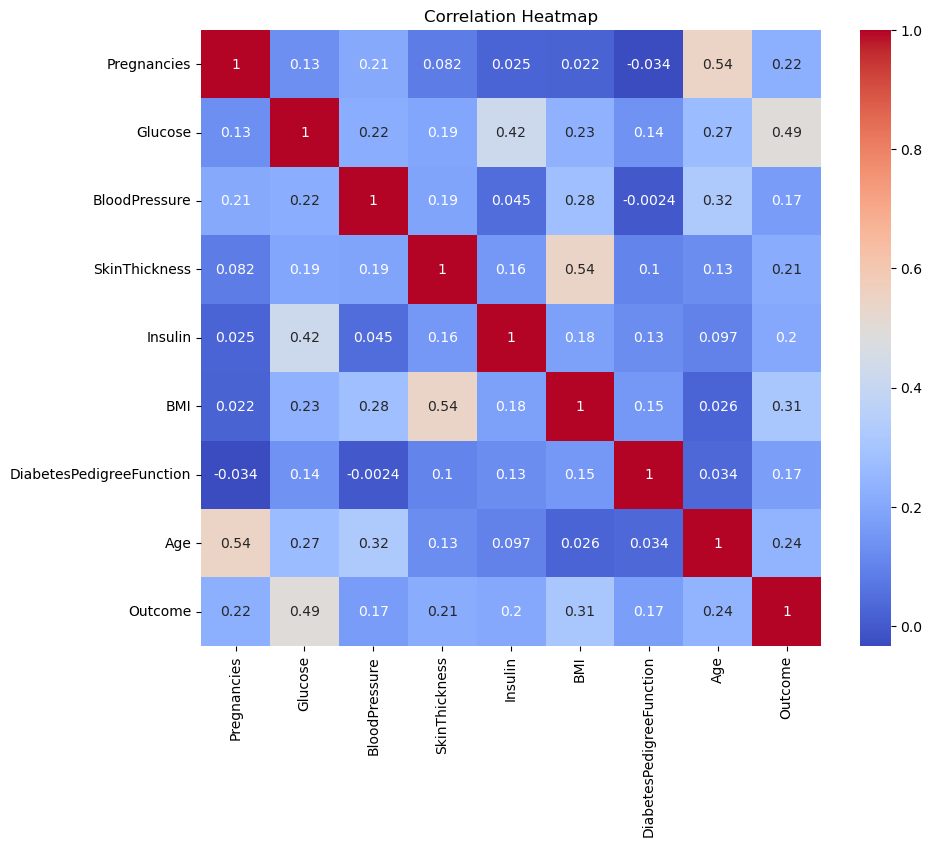

In [20]:
# =========================
# Correlation Heatmap
# =========================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

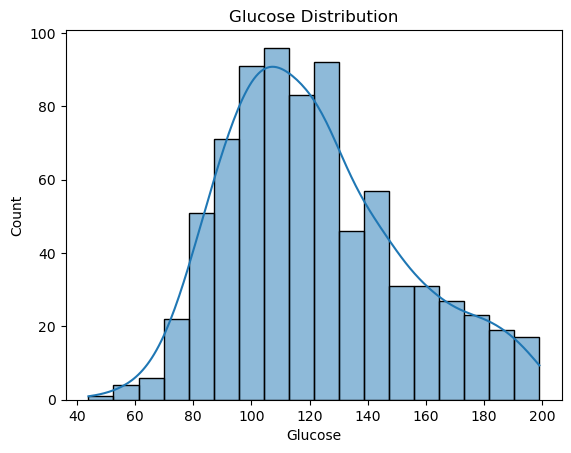

In [21]:
# =========================
# Distribution Plot
# =========================

plt.figure() 
sns.histplot(df['Glucose'], kde=True)
plt.title("Glucose Distribution")
plt.show()

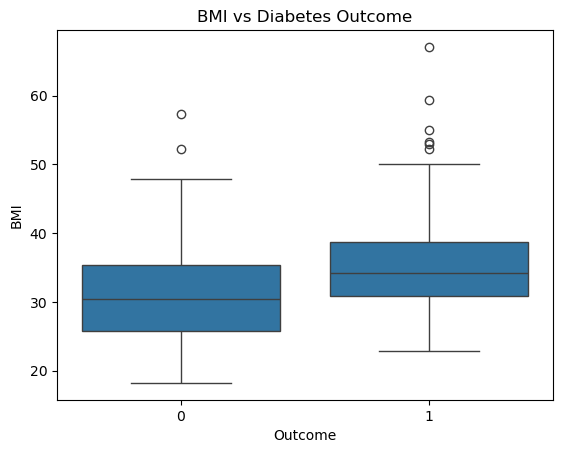

In [22]:
# =========================
# Boxplot
# =========================

plt.figure()
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Diabetes Outcome")
plt.show()

In [23]:
# =========================
# Prepare Data
# =========================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [24]:
# =========================
# Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# =========================
# Random Forest Model
# =========================

model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [26]:
# =========================
# Evaluation
# =========================

print("\n--- Model Evaluation Results ---")
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))
print("-" * 30)


--- Model Evaluation Results ---
Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154

------------------------------


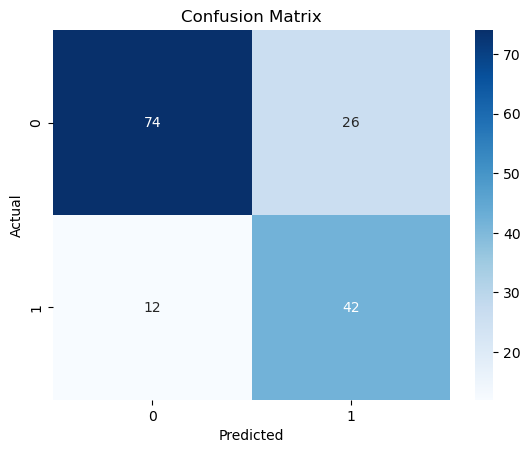

In [12]:
# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
# =========================
# Feature Importance
# =========================

importance = model.named_steps['rf'].feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n--- Feature Importance Ranking ---")
print(importance_df)
print("-" * 30)


--- Feature Importance Ranking ---
                    Feature  Importance
1                   Glucose    0.324514
5                       BMI    0.192162
7                       Age    0.129087
4                   Insulin    0.098173
6  DiabetesPedigreeFunction    0.085419
3             SkinThickness    0.066664
2             BloodPressure    0.064322
0               Pregnancies    0.039659
------------------------------


In [29]:
# =========================
# Standardization
# =========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

F:\python\anaconda\anacondainvest\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


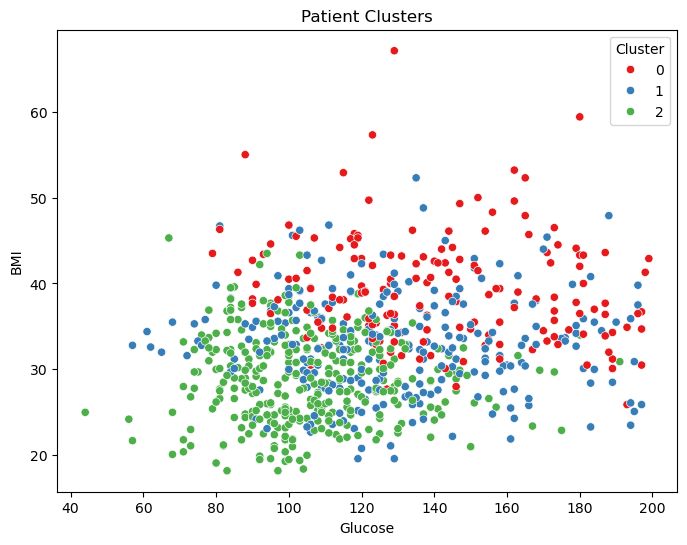

In [31]:
# =========================
# Cluster Visualization
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Glucose'],
    y=df['BMI'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Patient Clusters")

plt.show()